In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
from lightsim2grid import LightSimBackend
import grid2op as gp
gp.update_env()

Environment "rte_case14_realistic" is up to date
Environment "l2rpn_case14_sandbox" is up to date
Environment "rte_case14_redisp" is up to date
Successfully updated file "difficulty_levels.json" for environment "l2rpn_neurips_2020_track1_small"


In [3]:
backend = LightSimBackend()
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)

In [4]:
# Corrected hard overflow limit
env.parameters.HARD_OVERFLOW_THRESHOLD

2.0

In [5]:
# Init
env.set_id(0)
obs = env.reset()

In [6]:
obs.state_of(substation_id=4)

{'topo_vect': array([1, 1, 1, 1, 1, 1], dtype=int32),
 'nb_bus': 1,
 'cooldown_time': 0}

In [7]:
obs.state_of(line_id=2)

{'origin': {'p': -2.04,
  'q': -8.4800005,
  'v': 147.73917,
  'a': 34.08444,
  'bus': 1,
  'sub_id': 0},
 'extremity': {'p': 2.0562575,
  'q': 4.3043723,
  'v': 149.01659,
  'a': 18.482086,
  'bus': 1,
  'sub_id': 4},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

In [9]:
act = env.action_space({
    'set_bus': {
        'lines_ex_id': [
            (2, 2),
        ]
    }
})
print(act)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (extremity) 2 [on substation 4]


In [10]:
env.step(act)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7fe4ebad86d8>,
 -10.0,
 True,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [Grid2OpException DivergingPowerFlow DivergingPowerFlow('GAME OVER: Powerflow has diverged during computation or a load has been disconnected or a generator has been disco

In [13]:
env.gen_cost_per_MW[env.gen_cost_per_MW>0].ptp()

13.0

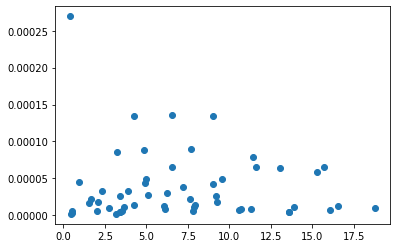

In [24]:
scatter(env.backend.init_pp_backend._grid.line.r_ohm_per_km, 1/env._thermal_limit_a[:55]**2)

In [ ]:
# Static graph analysis of the grid
def graph(obs):
    